In [1]:
import delaunay_rust as dnrst
import delaunay_cpp as dncpp
from visualization import draw_triangulation, display_triangulation_structure
import numpy as np
import pandas as pd

Przygotowanie punktów pod triangulacje

In [2]:
points_to_triangulate = np.random.rand(100, 2)

# Użycie biblioteki
Użycie funkcji bibliotecznych jest maksymalnie proste, na wejściu podajemy punkty do triangulacji i na wyjściu otrzymujemy strukturę reprezentującą indeksy punktów połączone w trójkąty

In [3]:
triangulation = dncpp.triangulate_points(points_to_triangulate)

Wyświetlmy wyniki

### **Struktura zbioru trójkątów (Indeksy punktów)**

,Wierzchołek A,Wierzchołek B,Wierzchołek C
0,0,6,9
1,6,0,15
2,6,15,25
3,4,24,27
4,26,20,29
...,...,...,...
181,20,68,99
182,22,73,99
183,73,8,99
184,46,22,99


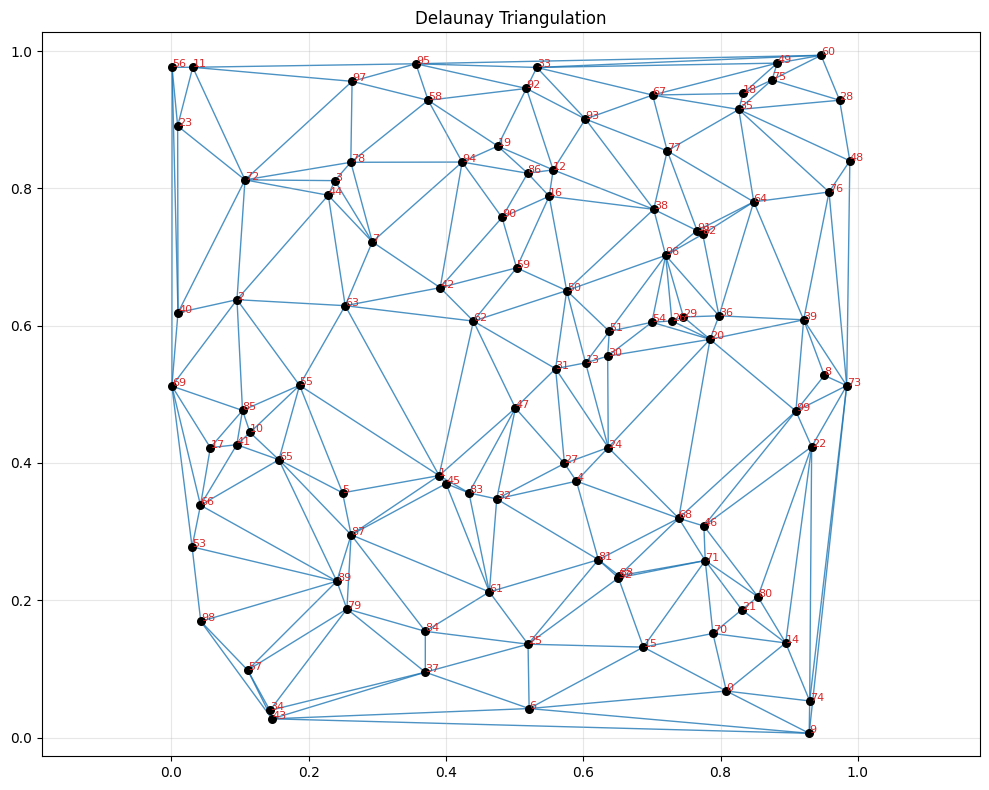

In [4]:
display_triangulation_structure(triangulation)
draw_triangulation(points_to_triangulate, triangulation)

Obie biblioteki posiadają funkcję triangulate_points i triangulate_points_dnc odpowiadające dwóm róznym metodom triangulacji
```python
triangulation = dncpp.triangulate_points(points_to_triangulate)
triangulation = dncpp.triangulate_points_dnc(points_to_triangulate)
triangulation = dnrst.triangulate_points(points_to_triangulate)
triangulation = dnrst.triangulate_points_dnc(points_to_triangulate)
```

Dodatkowo funkcje `triangulate_points` przyjmują argument `use_walk` determinujący sposób wykonania algorytmu

# Wydajność
Przetestowano wydajność funkcji bibliotecznych i porównano z implementacją w pythonie

In [5]:
from IPython.display import display, Markdown
with open("benchmark_wyniki.md", "r", encoding="utf-8") as f:
    text = f.read()

display(Markdown(text))

# Wyniki Benchmarku Algorytmów Triangulacji

## 1. Czas wykonania dla stałych rozmiarów siatki (w sekundach)

| Algorytm | N=100 | N=1000 | N=5000 | N=10000 |
|---| --- | --- | --- | --- |
| **Python (DNC)** | 0.0084s | 0.0871s | 0.5011s | 1.1001s |
| **Rust (DNC)** | 0.0002s | 0.0011s | 0.0078s | 0.0147s |
| **C++ (DNC)** | 0.0002s | 0.0015s | 0.0092s | 0.0191s |
| **Python (Bowyer-Watson)** | 0.0048s | 0.0618s | 0.6786s | 2.2801s |
| **Rust (Bowyer-Watson)** | 0.0003s | 0.0013s | 0.0110s | 0.0273s |
| **C++ (Bowyer-Watson)** | 0.0002s | 0.0015s | 0.0117s | 0.0296s |

---

## 2. Maksymalny rozmiar siatki (N) policzony w czasie poniżej 2.0 sekund

| Algorytm | Max Liczba Punktów (N) |
|---|---|
| **Rust (DNC)** | 787 320 |
| **C++ (DNC)** | 656 100 |
| **C++ (Bowyer-Watson)** | 145 800 |
| **Rust (Bowyer-Watson)** | 121 500 |
| **Python (DNC)** | 14 580 |
| **Python (Bowyer-Watson)** | 8 100 |


Można zaobserwować że dla algorytmów wymagających dużej ilości operacji geometrycznych na krawędziach czysty python nie jest nawet bliski wydajności obu języków.

# Wnioski

Największą przewagą rusta dla osoby uczącej się obydwu języków jest brak 40-letniej wstecznej kompatybilności jak ma to miejsce w c++.
Dodatkowo mimo że rust jest bardziej ograniczający, powiedziałbym że dla nowego programisty zmienia się to w wolnośc. Pisząc w c++ programista musi cały czas trzymać się na baczności i wiedzieć dokładnie jakie dodatkowe problemy może wywołać linijka kodu którą właśnie napisał.

Implementacja quad_edge w pythonie używa cyklicznych referencji, czego postanowiłem uniknąć zarówno w implementacji w rust i c++, w tym celu powstała struktura EdgeEntry która jest krótko-żyjącą zmienną dającą abstrakcje nad konkretnymi krawędziami w strukturze danych.

```rust
struct EdgeEntry {
    edge_index: u8,
    quad_edge_key: QEGraphKey,
    [...]
}
```

Podczas implementacji algorytmu divide and conquer w języku cpp postanowiłem że skorzystam ze wskaźników by nieco uładnić kod, co w ruście było problemem.

```cpp
class EdgeEntry {
    private:
        QuadEdgeGraph* graph;
        Key qe_key;
        uint8_t index = 0;
    [...]
}
```

Wszystkie instancje tych obiektów trzymają wskaźnik do tego samego obiektu więc dla bezpieczeństwa chciałem użyć shared_pointer,
ku mojemu zaskoczeniu algorytm po zmianie na ten typ referencji spowolnił około 3 razy. Pokazuje to że nawet jeżeli istnieje opcja podobna do referencji rusta w cpp to gdybym nie przetestowal wydajności nie wiedziałbym nawet że kryje się za nią znaczący dodatkowy koszt.

Dla porównania wyniki z shared_pointer
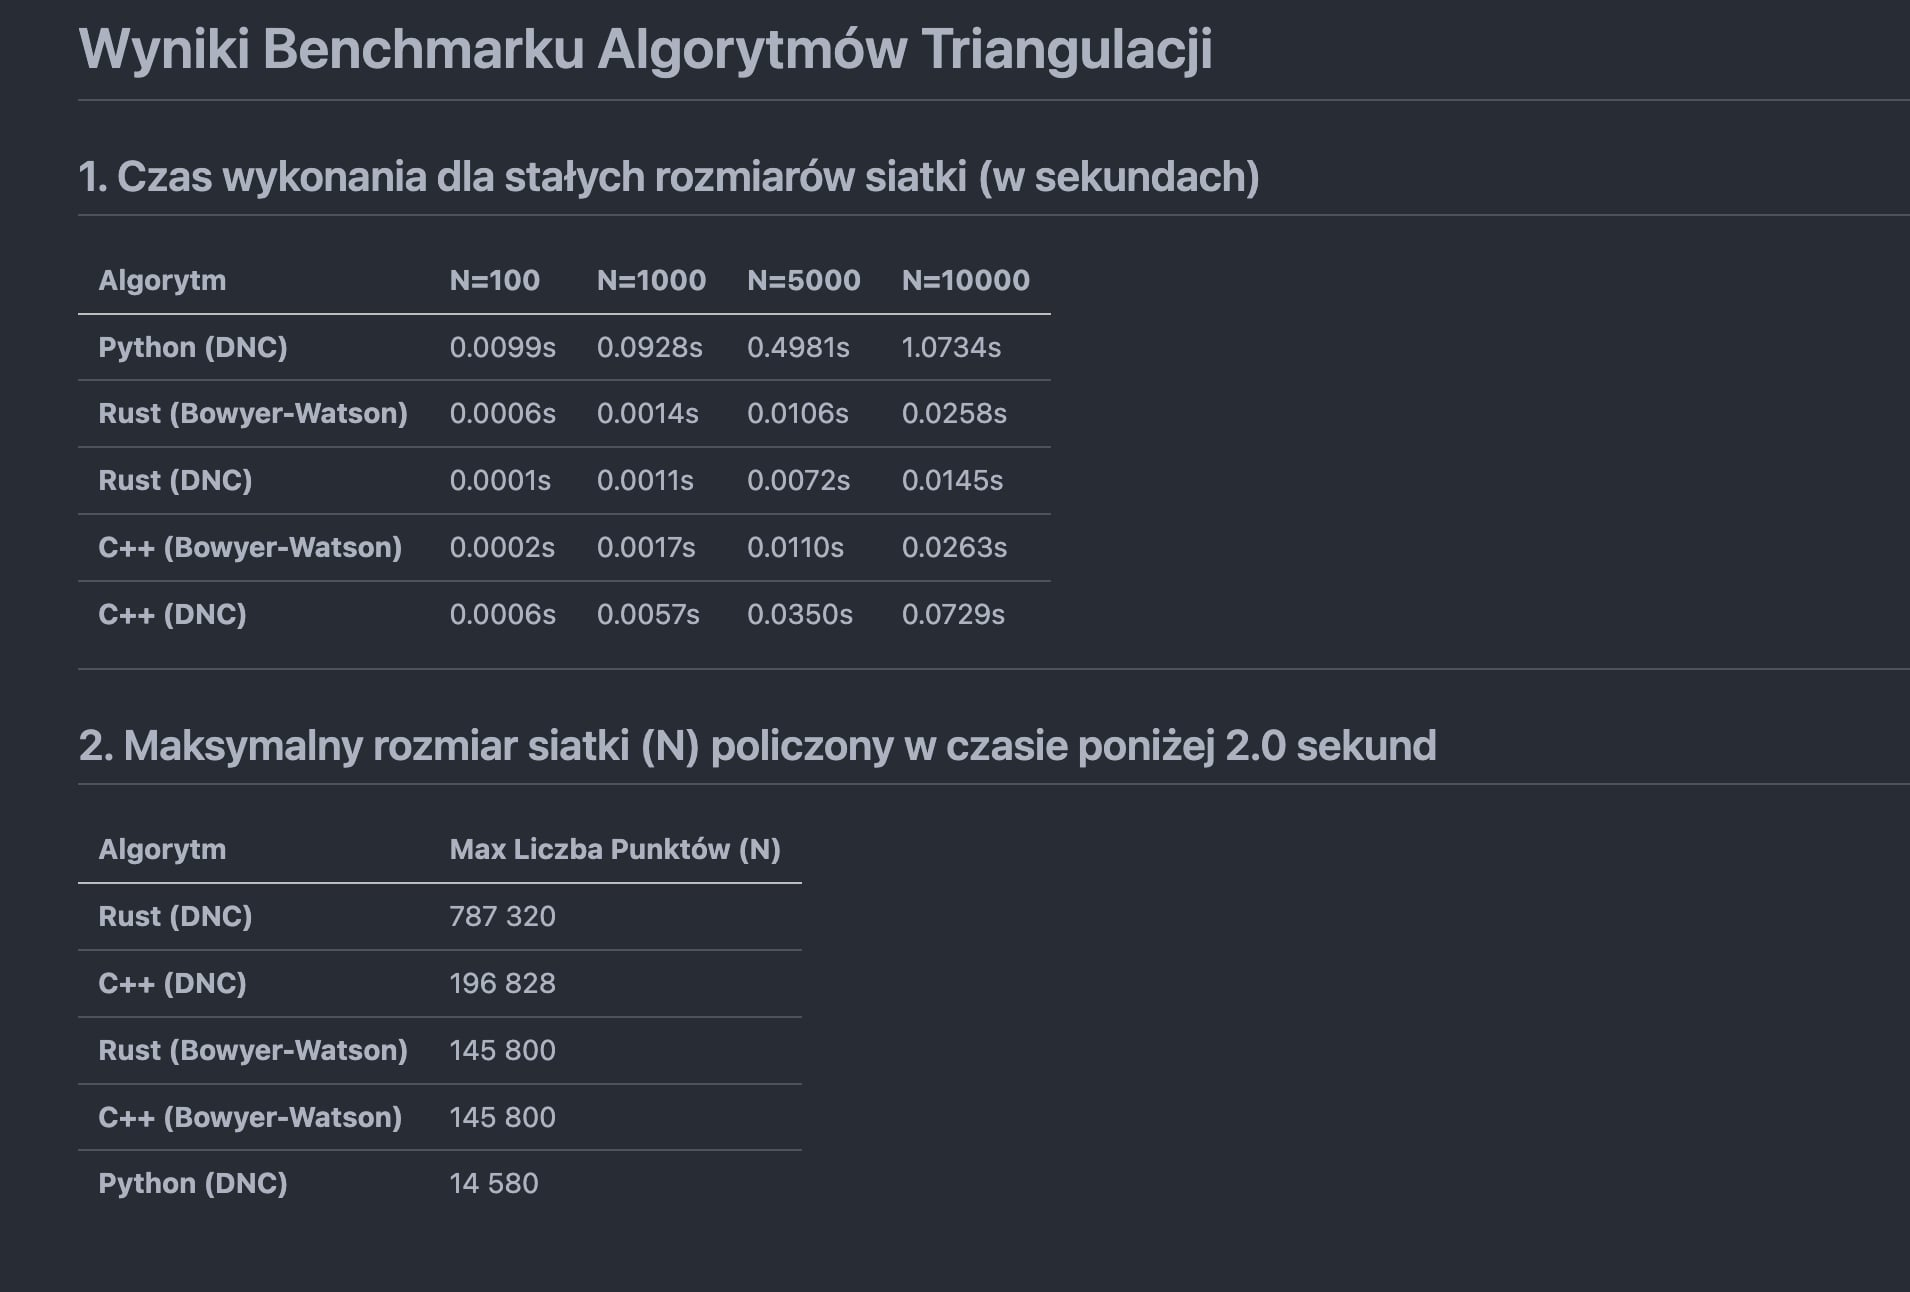